# CDS 3543 – Data Visualization for Decision Making


In [1]:
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
warnings.filterwarnings("ignore")

## Deliverable 2

### Data Loading & Inspection

In [2]:
df = pd.read_csv('data/student_habits_performance.csv')
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [3]:
# basic details
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [4]:
# dataset shape
print(f"Dataset shape: {df.shape}")

Dataset shape: (1000, 16)


In [5]:
# statistics summary
df.describe(include='all')

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
count,1000,1000.0000,1000,1000.00000,1000.000000,1000.000000,1000,1000.000000,1000.000000,1000,1000.000000,909,1000,1000.000000,1000,1000.000000
unique,1000,NaN,3,NaN,NaN,NaN,2,NaN,NaN,3,NaN,3,3,NaN,2,NaN
top,S1000,NaN,Female,NaN,NaN,NaN,No,NaN,NaN,Fair,NaN,High School,Good,NaN,No,NaN
freq,1,NaN,481,NaN,NaN,NaN,785,NaN,NaN,437,NaN,392,447,NaN,682,NaN
mean,NaN,20.4980,NaN,3.55010,2.505500,1.819700,NaN,84.131700,6.470100,NaN,3.042000,NaN,NaN,5.438000,NaN,69.601500
std,NaN,2.3081,NaN,1.46889,1.172422,1.075118,NaN,9.399246,1.226377,NaN,2.025423,NaN,NaN,2.847501,NaN,16.888564
min,NaN,17.0000,NaN,0.00000,0.000000,0.000000,NaN,56.000000,3.200000,NaN,0.000000,NaN,NaN,1.000000,NaN,18.400000
25%,NaN,18.7500,NaN,2.60000,1.700000,1.000000,NaN,78.000000,5.600000,NaN,1.000000,NaN,NaN,3.000000,NaN,58.475000
50%,NaN,20.0000,NaN,3.50000,2.500000,1.800000,NaN,84.400000,6.500000,NaN,3.000000,NaN,NaN,5.000000,NaN,70.500000
75%,NaN,23.0000,NaN,4.50000,3.300000,2.525000,NaN,91.025000,7.300000,NaN,5.000000,NaN,NaN,8.000000,NaN,81.325000


In [6]:
# unique values for categorical columns
for col in df.select_dtypes(include=['object', 'string']):
    print(col, df[col].unique())

student_id ['S1000' 'S1001' 'S1002' 'S1003' 'S1004' 'S1005' 'S1006' 'S1007' 'S1008'
 'S1009' 'S1010' 'S1011' 'S1012' 'S1013' 'S1014' 'S1015' 'S1016' 'S1017'
 'S1018' 'S1019' 'S1020' 'S1021' 'S1022' 'S1023' 'S1024' 'S1025' 'S1026'
 'S1027' 'S1028' 'S1029' 'S1030' 'S1031' 'S1032' 'S1033' 'S1034' 'S1035'
 'S1036' 'S1037' 'S1038' 'S1039' 'S1040' 'S1041' 'S1042' 'S1043' 'S1044'
 'S1045' 'S1046' 'S1047' 'S1048' 'S1049' 'S1050' 'S1051' 'S1052' 'S1053'
 'S1054' 'S1055' 'S1056' 'S1057' 'S1058' 'S1059' 'S1060' 'S1061' 'S1062'
 'S1063' 'S1064' 'S1065' 'S1066' 'S1067' 'S1068' 'S1069' 'S1070' 'S1071'
 'S1072' 'S1073' 'S1074' 'S1075' 'S1076' 'S1077' 'S1078' 'S1079' 'S1080'
 'S1081' 'S1082' 'S1083' 'S1084' 'S1085' 'S1086' 'S1087' 'S1088' 'S1089'
 'S1090' 'S1091' 'S1092' 'S1093' 'S1094' 'S1095' 'S1096' 'S1097' 'S1098'
 'S1099' 'S1100' 'S1101' 'S1102' 'S1103' 'S1104' 'S1105' 'S1106' 'S1107'
 'S1108' 'S1109' 'S1110' 'S1111' 'S1112' 'S1113' 'S1114' 'S1115' 'S1116'
 'S1117' 'S1118' 'S1119' 'S1120' 'S1121'

In [7]:
# check for duplicates
df.duplicated().sum()

np.int64(0)

### Data Preprocessing

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [9]:
# drop student_id column
df = df.drop(columns=['student_id'])

In [10]:
# rename columns
df = df.rename(columns={'study_hours_per_day': 'study_hours', 'extracurricular_participation': 'extra_acts', 'parental_education_level': 'parent_education', 'attendance_percentage': 'attendance', 'mental_health_score': 'mental_health'})
df.columns

Index(['age', 'gender', 'study_hours', 'social_media_hours', 'netflix_hours',
       'part_time_job', 'attendance', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parent_education', 'internet_quality',
       'mental_health_rating', 'extra_acts', 'exam_score'],
      dtype='object')

In [11]:
# encode gender, part_time_job, diet_quality, parent_education, internet_quality, extra_acts
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})
df['part_time_job'] = df['part_time_job'].map({'No': 0, 'Yes': 1})
df['diet_quality'] = df['diet_quality'].map({'Poor': 0, 'Fair': 1, 'Good': 2})
education_mapping = {'High School': 0, 'Bachelor': 1, 'Master': 2}
df['parent_education'] = df['parent_education'].map(education_mapping)
df['internet_quality'] = df['internet_quality'].map({'Poor': 0, 'Average': 1, 'Good': 2})
df['extra_acts'] = df['extra_acts'].map({'No': 0, 'Yes': 1})
df.head()

,age,gender,study_hours,social_media_hours,netflix_hours,part_time_job,attendance,sleep_hours,diet_quality,exercise_frequency,parent_education,internet_quality,mental_health_rating,extra_acts,exam_score
0,23,1.0,0.0,1.2,1.1,0,85.0,8.0,1,6,2.0,1,8,1,56.2
1,20,1.0,6.9,2.8,2.3,0,97.3,4.6,2,6,0.0,1,8,0,100.0
2,21,0.0,1.4,3.1,1.3,0,94.8,8.0,0,1,0.0,0,1,0,34.3
3,23,1.0,1.0,3.9,1.0,0,71.0,9.2,0,4,2.0,2,1,1,26.8
4,19,1.0,5.0,4.4,0.5,0,90.9,4.9,1,3,2.0,2,1,0,66.4


In [12]:
# check for null values again
df.isnull().sum()

age                      0
gender                  42
study_hours              0
social_media_hours       0
netflix_hours            0
part_time_job            0
attendance               0
sleep_hours              0
diet_quality             0
exercise_frequency       0
parent_education        91
internet_quality         0
mental_health_rating     0
extra_acts               0
exam_score               0
dtype: int64

In [13]:
# impute null values in parental_education with the most frequent value
most_frequent_value = df['parent_education'].mode()[0]
df['parent_education'] = df['parent_education'].fillna(most_frequent_value)

In [14]:
# drop null values in gender
df = df[df['gender'].notnull()]

In [15]:
# check nulls again
df.isnull().sum()

age                     0
gender                  0
study_hours             0
social_media_hours      0
netflix_hours           0
part_time_job           0
attendance              0
sleep_hours             0
diet_quality            0
exercise_frequency      0
parent_education        0
internet_quality        0
mental_health_rating    0
extra_acts              0
exam_score              0
dtype: int64

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 958 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   958 non-null    int64  
 1   gender                958 non-null    float64
 2   study_hours           958 non-null    float64
 3   social_media_hours    958 non-null    float64
 4   netflix_hours         958 non-null    float64
 5   part_time_job         958 non-null    int64  
 6   attendance            958 non-null    float64
 7   sleep_hours           958 non-null    float64
 8   diet_quality          958 non-null    int64  
 9   exercise_frequency    958 non-null    int64  
 10  parent_education      958 non-null    float64
 11  internet_quality      958 non-null    int64  
 12  mental_health_rating  958 non-null    int64  
 13  extra_acts            958 non-null    int64  
 14  exam_score            958 non-null    float64
dtypes: float64(8), int64(7)
memo

### Visualize

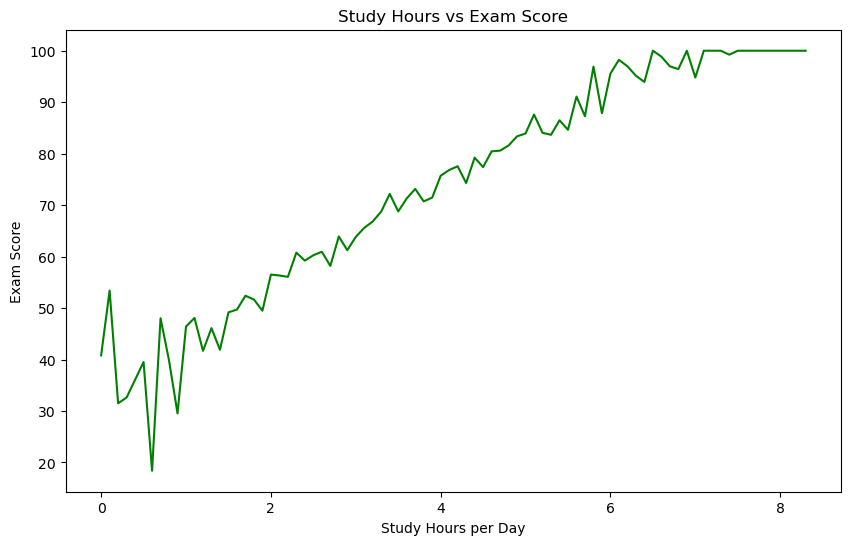

In [17]:
# line chart for study_hours vs exam_score sorted by study_hours
plt.figure(figsize=(10, 6))
sns.lineplot(
    x='study_hours', 
    y='exam_score', 
    data=df.sort_values('study_hours'), 
    errorbar=None,
    color='green'
    )

plt.title('Study Hours vs Exam Score')
plt.xlabel('Study Hours per Day')
plt.ylabel('Exam Score')
plt.show()

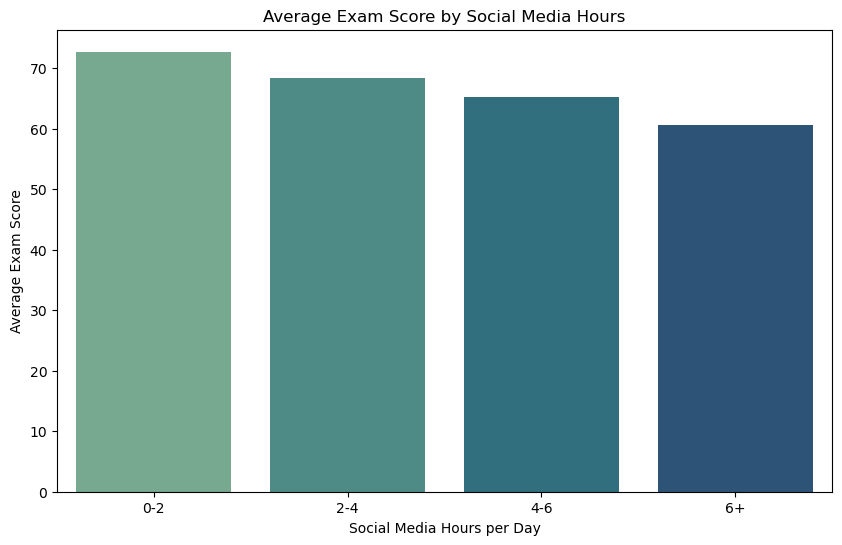

In [18]:
# average exam score by social media hours binned into 0-2, 2-4, 4-6, 6+ hours
df['social_media_hours_bin'] = pd.cut(df['social_media_hours'], bins=[-1, 2, 4, 6, np.inf], labels=['0-2', '2-4', '4-6', '6+'])
avg_scores = df.groupby('social_media_hours_bin')['exam_score'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(
    x='social_media_hours_bin', 
    y='exam_score', 
    data=avg_scores, 
    hue='social_media_hours_bin', 
    palette='crest',  #mako_r OR crest OR Spectral_r 
    legend=False
)
plt.title('Average Exam Score by Social Media Hours')
plt.xlabel('Social Media Hours per Day')
plt.ylabel('Average Exam Score')
plt.show()


# drop social_media_hours_bin
df = df.drop(columns=['social_media_hours_bin'])

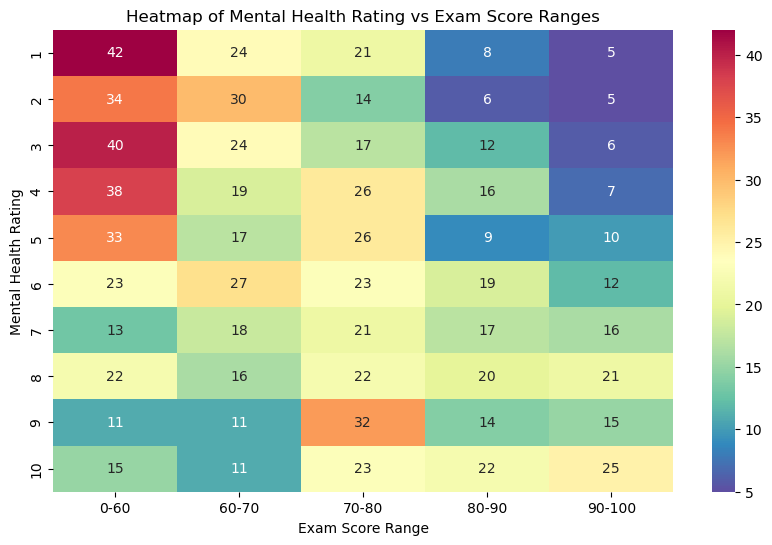

In [19]:
# heatmap of mental_health_rating vs exam_score ranges
df['exam_score_range'] = pd.cut(df['exam_score'], bins=[0, 60, 70, 80, 90, 100], labels=['0-60', '60-70', '70-80', '80-90', '90-100'])
heatmap_data = df.groupby(['mental_health_rating', 'exam_score_range']).size().unstack(fill_value=0)
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='Spectral_r')
plt.title('Heatmap of Mental Health Rating vs Exam Score Ranges')
plt.xlabel('Exam Score Range')
plt.ylabel('Mental Health Rating')
plt.show()

# drop exam_score_range
df = df.drop(columns=['exam_score_range'])

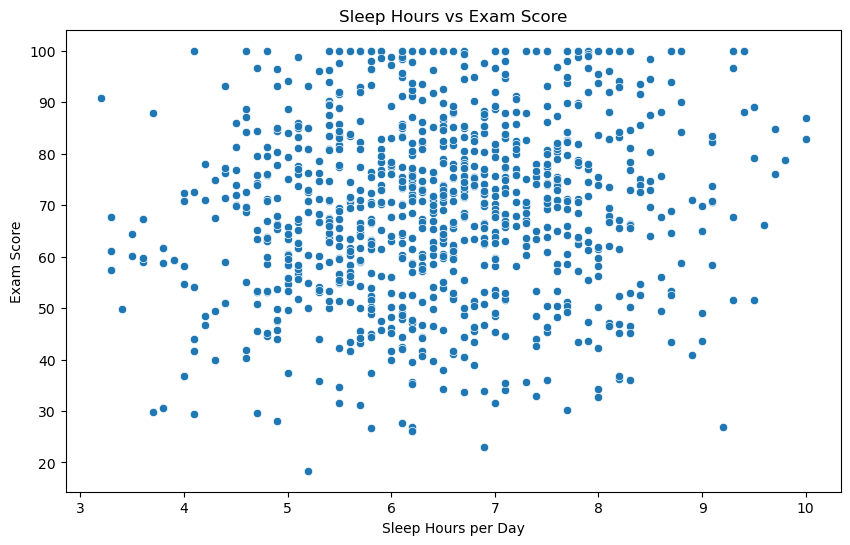

In [20]:
# scatter plot of sleep_hours vs exam_score
plt.figure(figsize=(10, 6))
sns.scatterplot(x='sleep_hours', y='exam_score', data=df)
plt.title('Sleep Hours vs Exam Score')
plt.xlabel('Sleep Hours per Day')
plt.ylabel('Exam Score')
plt.show()

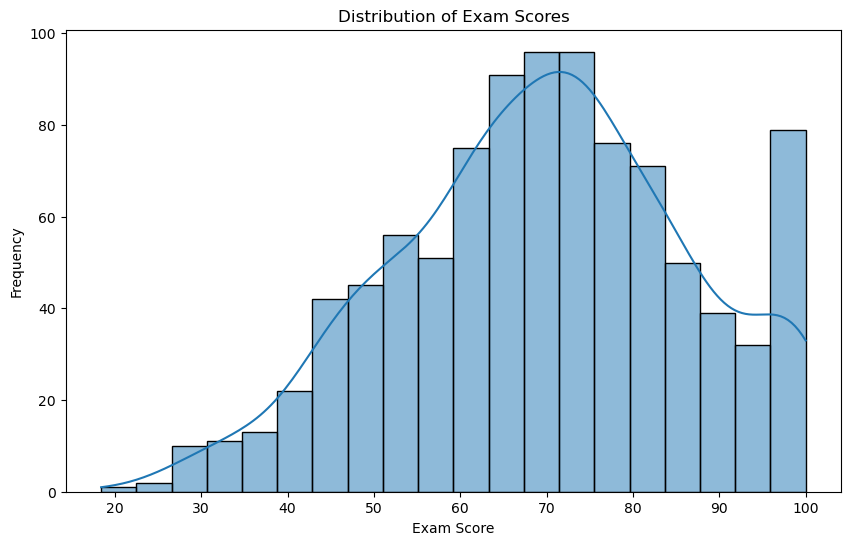

In [21]:
# exam score distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['exam_score'], bins=20, kde=True)
plt.title('Distribution of Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')
plt.show()

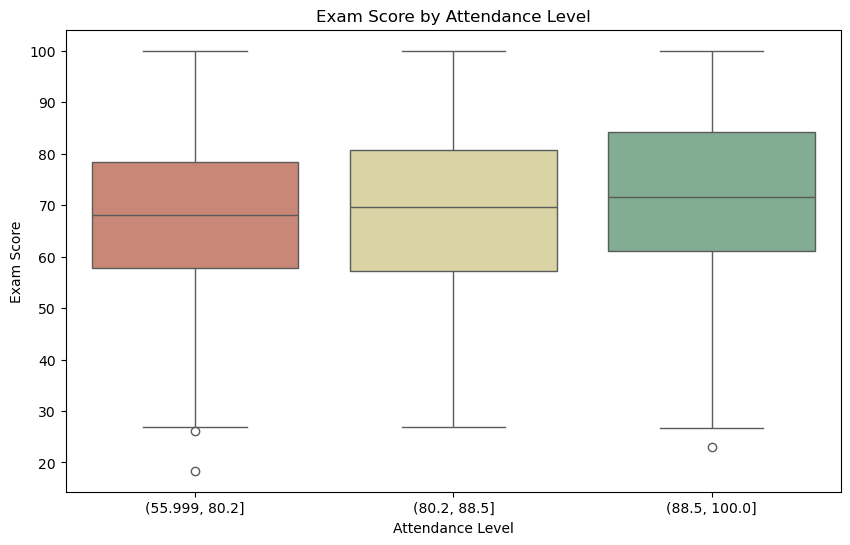

In [22]:
# exam score by attendance level, attendance binned into 3 quantiles
df['attendance_group'] = pd.qcut(df['attendance'], q=3)

plt.figure(figsize=(10,6))
sns.boxplot(x='attendance_group', y='exam_score', data=df, palette=["#d67f6b", "#e1d99e", "#7bb490"]) 

plt.title('Exam Score by Attendance Level')
plt.xlabel('Attendance Level')
plt.ylabel('Exam Score')
plt.show()

# drop attendance_group column
df = df.drop(columns=['attendance_group'])

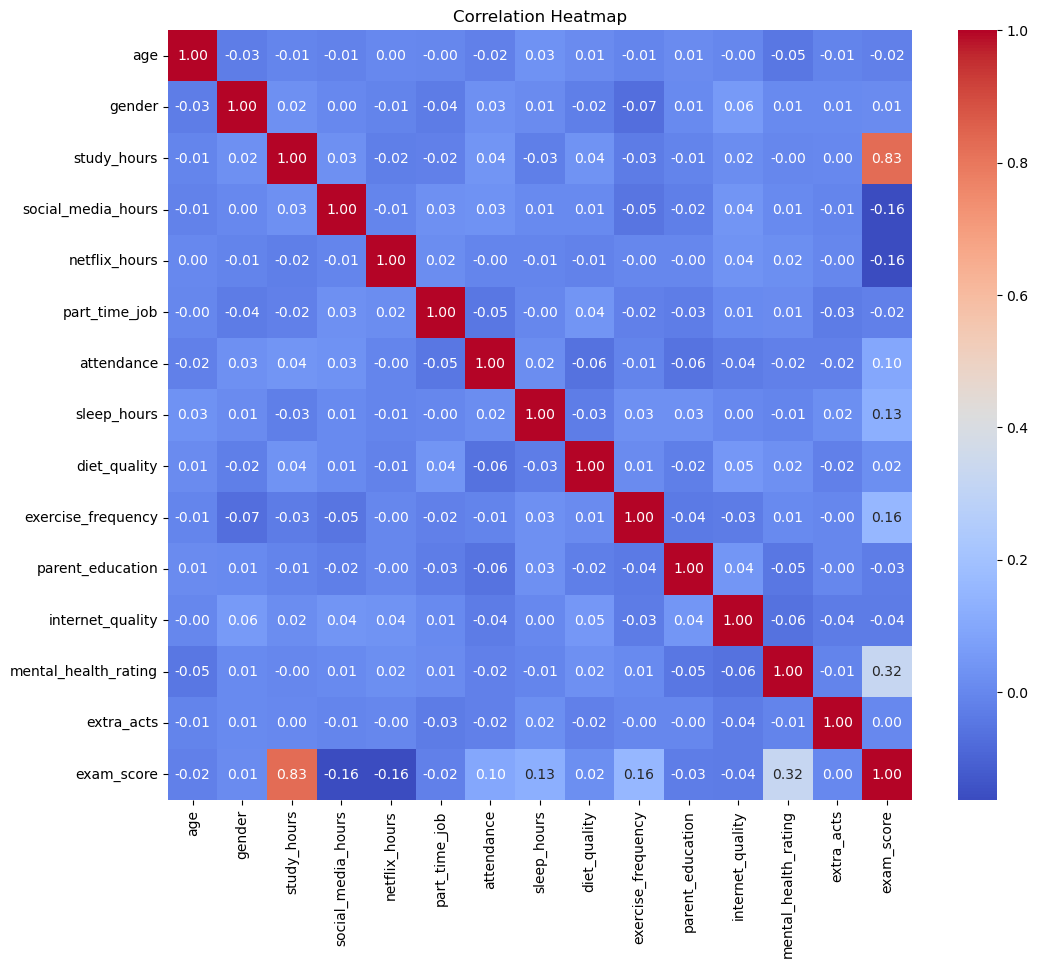

In [23]:
# correlation heatmap for everything
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### Build a Dashboard Using Plotly

In [24]:
import dash
from dash import html, dcc
import plotly.express as px
import pandas as pd
import webbrowser


# --- Data Prep ---
df['social_media_hours_bin'] = pd.cut(
    df['social_media_hours'],
    bins=[0, 2, 4, 6, 10],
    labels=['0-2', '2-4', '4-6', '6+']
)
avg_scores = df.groupby('social_media_hours_bin', observed=False)['exam_score'].mean().reset_index()

df['score_range'] = pd.cut(
    df['exam_score'],
    bins=[0, 60, 70, 80, 90, 100],
    labels=['0-60', '60-70', '70-80', '80-90', '90-100']
)
heatmap_data = pd.crosstab(df['mental_health_rating'], df['score_range'])

df['attendance_group'] = pd.cut(
    df['attendance'],
    bins=[0, 80, 88, 100],
    labels=['Low', 'Medium', 'High']
)

df['study_hours_rounded'] = df['study_hours'].round()
study_avg = df.groupby('study_hours_rounded')['exam_score'].mean().reset_index()

# --- Color Mapping ---
color_map = {
    'Low': '#d67f6b',
    'Medium': '#e1d99e',
    'High': '#7bb490'
}

common_layout = dict(
    template='simple_white',
    font=dict(family='Tahoma'),
    title_font=dict(family='Tahoma', size=18, color='black'),
)

app = dash.Dash(__name__)

app.layout = html.Div([
    # Header
    html.Div(
        html.H1('Student Habits and Performance Dashboard', 
                style={'textAlign': 'center', 'fontFamily': 'Tahoma', 'margin': '0'}),
        style={'backgroundColor': '#E8F0FE', 'padding': '15px', 'borderRadius': '10px', 'marginBottom': '20px'}
    ),

    # Top Row
    html.Div([
        dcc.Graph(
            figure=px.line(
                study_avg,
                x='study_hours_rounded',
                y='exam_score',
                markers=True,
                title='<b>Study Hours vs Exam Score</b>',
                color_discrete_sequence=['green'] 
            ).update_layout(**common_layout),
            style={'width': '50%'}
        ),
        dcc.Graph(
            figure=px.bar(
                avg_scores,
                x='social_media_hours_bin',
                y='exam_score',
                color='social_media_hours_bin',
                title='<b>Average Score by Social Media Hours</b>',
                color_discrete_sequence=['#82ac91', '#5e8d8d', '#406e7e', '#324b67']
            ).update_layout(**common_layout, showlegend=False),
            style={'width': '50%'}
        ),
    ], style={'display': 'flex'}),

    # Bottom Row
    html.Div([
        dcc.Graph(
            figure=px.imshow(
                heatmap_data,
                text_auto=True,
                color_continuous_scale='Spectral_r', 
                title='<b>Mental Health vs Score</b>'
            ).update_layout(**common_layout),
            style={'width': '50%'}
        ),
        dcc.Graph(
            figure=px.box(
                df,
                x='attendance_group',
                y='exam_score',
                color='attendance_group',
                color_discrete_map=color_map, 
                title='<b>Exam Score by Attendance Level</b>',
                category_orders={"attendance_group": ["Low", "Medium", "High"]}
            ).update_layout(**common_layout, showlegend=False),
            style={'width': '50%'}
        ),
    ], style={'display': 'flex'})
])

if __name__ == '__main__':
    webbrowser.open_new('http://127.0.0.1:8050/')
    app.run(debug=True)

### Seaborn & Matplotlib Dashboard

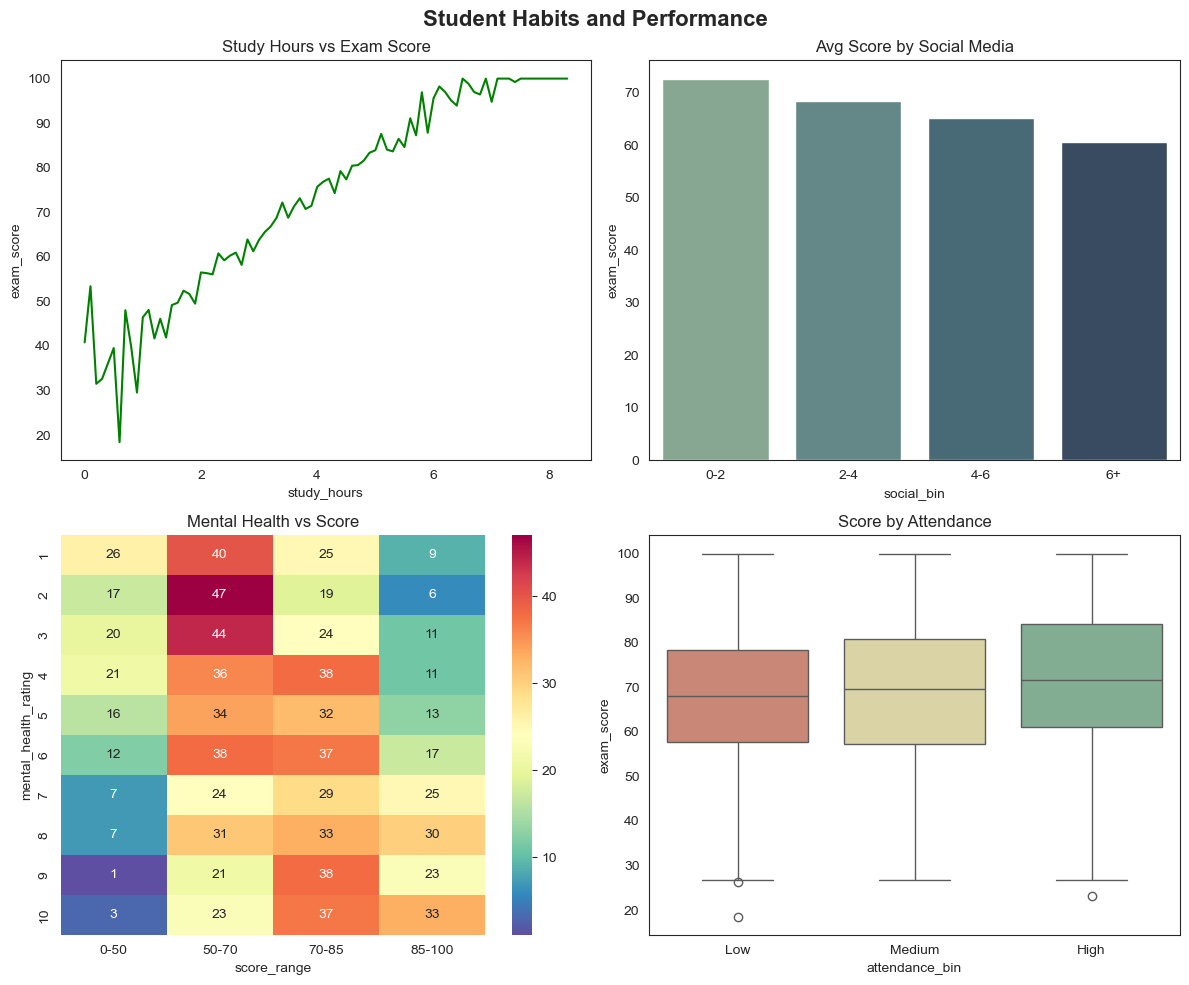

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("white")  # clean background

fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # dashboard layout

# line chart
sns.lineplot(data=df, x="study_hours", y="exam_score", ax=axes[0, 0], errorbar=None, color='green')
axes[0, 0].set_title("Study Hours vs Exam Score")

# bar chart
bins = [0, 2, 4, 6, float("inf")]
labels = ["0-2", "2-4", "4-6", "6+"]
df["social_bin"] = pd.cut(df["social_media_hours"], bins=bins, labels=labels)
avg_scores = df.groupby("social_bin")["exam_score"].mean().reset_index()

sns.barplot(data=avg_scores, x="social_bin", y="exam_score", ax=axes[0, 1], palette=['#82ac91', '#5e8d8d', '#406e7e', '#324b67'])
axes[0, 1].set_title("Avg Score by Social Media")

# heatmap
score_bins = [0, 50, 70, 85, 100]
score_labels = ["0-50", "50-70", "70-85", "85-100"]
df["score_range"] = pd.cut(df["exam_score"], bins=score_bins, labels=score_labels)
heatmap_data = pd.crosstab(df["mental_health_rating"], df["score_range"])

sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="Spectral_r", ax=axes[1, 0]) #'#82ac91', '#5e8d8d', '#406e7e', '#324b67'
axes[1, 0].set_title("Mental Health vs Score")

# box plot
df["attendance_bin"] = pd.qcut(df["attendance"], q=3, labels=["Low", "Medium", "High"])
sns.boxplot(data=df, x="attendance_bin", y="exam_score", palette=["#d67f6b", "#e1d99e", "#7bb490"], ax=axes[1, 1])
axes[1, 1].set_title("Score by Attendance")

plt.suptitle("Student Habits and Performance", fontsize=16, fontweight="bold")  # main title
plt.tight_layout()
plt.show()

## Deliverable 3

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 958 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   age                     958 non-null    int64   
 1   gender                  958 non-null    float64 
 2   study_hours             958 non-null    float64 
 3   social_media_hours      958 non-null    float64 
 4   netflix_hours           958 non-null    float64 
 5   part_time_job           958 non-null    int64   
 6   attendance              958 non-null    float64 
 7   sleep_hours             958 non-null    float64 
 8   diet_quality            958 non-null    int64   
 9   exercise_frequency      958 non-null    int64   
 10  parent_education        958 non-null    float64 
 11  internet_quality        958 non-null    int64   
 12  mental_health_rating    958 non-null    int64   
 13  extra_acts              958 non-null    int64   
 14  exam_score              958 non

In [27]:
# drop social_media_hours_bin, social_bin, score_range, attendance_group, study_hours_rounded, attendance_bin
df = df.drop(columns=['social_media_hours_bin', 'social_bin', 'score_range', 'attendance_group', 'study_hours_rounded', 'attendance_bin'])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 958 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   958 non-null    int64  
 1   gender                958 non-null    float64
 2   study_hours           958 non-null    float64
 3   social_media_hours    958 non-null    float64
 4   netflix_hours         958 non-null    float64
 5   part_time_job         958 non-null    int64  
 6   attendance            958 non-null    float64
 7   sleep_hours           958 non-null    float64
 8   diet_quality          958 non-null    int64  
 9   exercise_frequency    958 non-null    int64  
 10  parent_education      958 non-null    float64
 11  internet_quality      958 non-null    int64  
 12  mental_health_rating  958 non-null    int64  
 13  extra_acts            958 non-null    int64  
 14  exam_score            958 non-null    float64
dtypes: float64(8), int64(7)
memo

In [28]:
# detect outliers in exam_score using IQR method
Q1 = df['exam_score'].quantile(0.25)
Q3 = df['exam_score'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['exam_score'] < lower_bound) | (df['exam_score'] > upper_bound)]
print(f"Number of outliers in exam_score: {outliers.shape[0]}")

# drop outliers
df = df[(df['exam_score'] >= lower_bound) & (df['exam_score'] <= upper_bound)]
print(f"Dataset shape after dropping outliers: {df.shape}")

Number of outliers in exam_score: 2
Dataset shape after dropping outliers: (956, 15)


In [29]:
# filter to find students with high grades
high_performers = df[df['exam_score'] > 80]
high_performers

,age,gender,study_hours,social_media_hours,netflix_hours,part_time_job,attendance,sleep_hours,diet_quality,exercise_frequency,parent_education,internet_quality,mental_health_rating,extra_acts,exam_score
1,20,1.0,6.9,2.8,2.3,0,97.3,4.6,2,6,0.0,1,8,0,100.0
5,24,0.0,7.2,1.3,0.0,0,82.9,7.4,1,1,2.0,1,4,0,100.0
6,21,1.0,5.6,1.5,1.4,1,85.8,6.5,2,2,2.0,0,4,0,89.8
9,18,1.0,4.8,3.1,1.3,0,95.4,7.5,2,5,1.0,2,10,1,100.0
21,21,0.0,5.6,2.1,2.4,0,95.6,7.2,1,1,0.0,2,3,0,82.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
980,20,1.0,3.7,3.5,2.5,0,93.0,5.2,0,6,0.0,2,10,1,81.0
982,20,1.0,3.8,2.4,2.2,1,91.5,8.6,1,2,0.0,2,10,0,88.0
984,24,0.0,3.2,3.0,0.1,0,97.5,6.8,1,6,0.0,1,7,0,82.4
985,18,0.0,5.7,3.1,0.0,1,86.6,5.7,1,2,2.0,2,3,1,80.9


In [30]:
# find average exam score per study hour
exam_avg = df.groupby('study_hours')['exam_score'].mean()
exam_avg

study_hours
0.0     40.807692
0.1     53.400000
0.2     31.500000
0.3     32.625000
0.5     39.525000
          ...    
7.4     99.233333
7.5    100.000000
7.6    100.000000
8.2    100.000000
8.3    100.000000
Name: exam_score, Length: 77, dtype: float64

In [31]:
# rehsape to bin social media hours to categories
df['social_media_hours_bin'] = pd.cut(df['social_media_hours'], bins=[-1,2,4,6,np.inf])
df['social_media_hours_bin']

0      (-1.0, 2.0]
1       (2.0, 4.0]
2       (2.0, 4.0]
3       (2.0, 4.0]
4       (4.0, 6.0]
          ...     
995    (-1.0, 2.0]
996    (-1.0, 2.0]
997     (2.0, 4.0]
998     (4.0, 6.0]
999     (2.0, 4.0]
Name: social_media_hours_bin, Length: 956, dtype: category
Categories (4, interval[float64, right]): [(-1.0, 2.0] < (2.0, 4.0] < (4.0, 6.0] < (6.0, inf]]

<Axes: >

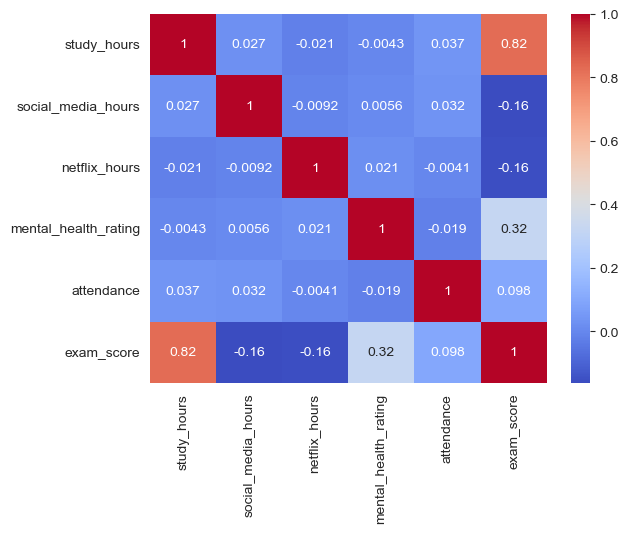

In [32]:
# statistical analysis
cols = ['study_hours', 'social_media_hours', 'netflix_hours', 'mental_health_rating', 'attendance', 'exam_score']
d3heatmap = sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm')
d3heatmap

In [44]:
# assumption 1: females study more than males

# Convert 0/1 to labels
df['gender_label'] = df['gender'].map({0: 'Male', 1: 'Female'})

# Group by labels
df_grouped = df.groupby('gender_label')['study_hours'].mean().reset_index()

# Plot
fig = px.bar(
    df_grouped,
    x='gender_label',
    y='study_hours',
    color='gender_label',
    title='Average Study Hours by Gender',
    color_discrete_map={
        'Male': 'lightblue',
        'Female': 'pink'
    }
)

fig.show()

In [34]:
# assumption 2: younger students have a higher average exam score than older students
# Create age bins
df['age_group'] = pd.cut(df['age'], bins=[0, 18, 22, 30], labels=['<18', '18-22', '22+'])
# Group by age group
age_avg = df.groupby('age_group')['exam_score'].mean().reset_index()
# Plot pie chart
fig = px.pie(
    age_avg,
    names='age_group',
    values='exam_score',
    title='Average Exam Score by Age Group',
    color_discrete_sequence=px.colors.sequential.RdBu
)
fig.show()

In [35]:
# assumption 3: higher internet quality is associated with higher exam scores
# group data
internet_avg = df.groupby('internet_quality')['exam_score'].mean().reset_index()

# map numbers to labels
internet_labels = {0: 'Poor', 1: 'Average', 2: 'Good'}
internet_avg['internet_quality_label'] = internet_avg['internet_quality'].map(internet_labels)

# plot
fig = px.bar(
    internet_avg,
    x='internet_quality_label',
    y='exam_score',
    title='Average Exam Score by Internet Quality',
    color='internet_quality_label',
    color_discrete_map={
        'Poor': '#EF553B',
        'Average': '#FECB52',
        'Good': '#00CC96'
    }
)

fig.show()

In [47]:
# average exam score by part time job
avg_scores = df.groupby('part_time_job')['exam_score'].mean().reset_index()

# map labels
avg_scores['part_time_job'] = avg_scores['part_time_job'].map({
    0: 'No',
    1: 'Yes'
})

# bar chart
fig = px.bar(
    avg_scores,
    x='part_time_job',
    y='exam_score',
    color='part_time_job',
    title='Average Exam Score by Part Time Job',
    labels={
        'part_time_job': 'Part Time Job',
        'exam_score': 'Average Exam Score'
    },
    color_discrete_map={
        #color-blind accessibility
        'No': '#D55E00',
        'Yes': '#009E73'
    }
)

fig.show()

In [42]:
# composition of students by diet quality
# map numbers to labels
diet_labels = {0: 'Poor', 1: 'Fair', 2: 'Good'}
df['diet_quality_label'] = df['diet_quality'].map(diet_labels)

# count students in each category
diet_counts = df['diet_quality_label'].value_counts().reset_index()

# rename columns
diet_counts.columns = ['diet', 'count']

# plot pie chart
fig = px.pie(
    diet_counts,
    names='diet',
    values='count',
    title='Distribution of Students by Diet Quality',
    color='diet',
    color_discrete_map={
        'Poor': '#EF553B',
        'Fair': '#FECB52',
        'Good': '#00CC96'
    }
)

fig.show()

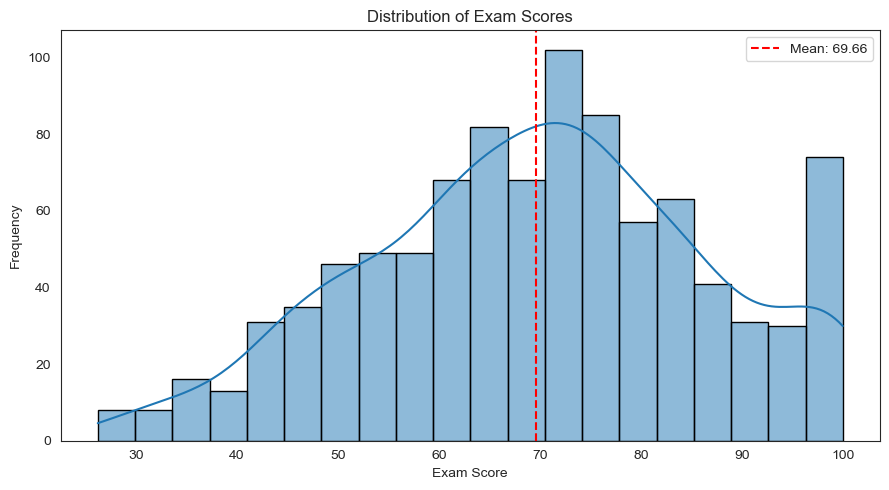

In [38]:
# exam score distribution
plt.figure(figsize=(9, 5))
sns.histplot(df['exam_score'], bins=20, kde=True,
             edgecolor='black')
plt.axvline(df['exam_score'].mean(), 
            color='red', linestyle='--', linewidth=1.5,
            label=f"Mean: {df['exam_score'].mean():.2f}") 
plt.title('Distribution of Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()